# Phase 1 — final runs vs. their hyperparameter-sweep seeds (Cologne-v1)

Phase 1 launches 3+ seeds of every algorithm on **Cologne-v1** with the winning
hyperparameter combo of the sweep. This notebook answers two questions:

1. **How far along is phase 1?** Which algorithms have been launched, how many
   seeds each has, and how much of training they have completed.
2. **Do the winning hyperparameters hold up on fresh seeds?** The sweep ranked
   each combo on 3 seeds, and the winner was picked on that basis — so the
   winner's sweep score is the maximum of 50 noisy estimates and is optimistically
   biased. The final-run seeds are an unbiased re-draw of the same configuration:
   if the combo is genuinely good rather than lucky, the two distributions
   overlap; if the final seeds sit clearly below the sweep seeds, the sweep
   ranking was largely selecting noise.

The comparison is per algorithm: the sweep combo's 3 seeds against the *n*
final-run seeds, as a box plot of the summary returns and as learning curves.

Data sources — sweep runs come from the tuning projects and reuse the cache of
`hyperparameter_tuning_analysis.ipynb` (`data/hyper_parameter_tuning/`); final
runs come from the phase-1 project into `data/final_runs/`. Both go through
`utils.wandb_utils` / `utils.run_data_handling`, same as the other notebooks.
Only *finished* runs are served from cache — anything still in flight is
re-downloaded on every execution, so re-running this notebook always shows
current progress.

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from tqdm.auto import tqdm
from utils.run_data_handling import Run
from utils.wandb_utils import download_run, store_run_data

api = wandb.Api()

In [85]:
ENTITY = "imp-act"
MAP_NAME = "Cologne-v1"  # phase 1 runs on Cologne-v1 only
METRIC = "test_returned_episode_returns"

# Phase-1 final runs. The training scripts build the project name as
# f"{PROJECT}_{map_name}", but runs trained offline are synced with the project
# name the sync script sets (unsuffixed), so every project starting with the
# prefix is collected and then filtered on the map.
FINAL_RUNS_PROJECT_PREFIX = "imp-act-jaxMARL-final-runs"
FINAL_RUNS_CACHE = Path("data/final_runs")

# Extra W&B filters on the final runs. Empty is right for phase 1, where the
# project holds nothing but the default-setting runs. Phase 3 adds unconstrained
# runs to the same project — narrow the selection here once they exist, so they
# do not get pooled with the default-setting seeds. The parity check below is
# the backstop: a run with different settings shows up there as a config diff.
EXTRA_FINAL_FILTERS = {}

# The sweep combo each final-run config was built from — the combo named in the
# header of the matching experiments/config/final_runs/*.yaml. Values are
# (sweep project, combo id); the two projects differ because the sweeps were
# synced to W&B by different people.
SWEEP_WINNERS = {
    "ippo_rnn": ("hyper_parameter_tuning", "C0054"),
    "mappo_rnn": ("hyper_parameter_tuning", "C0022"),
    "qmix_rnn": ("hyper_parameter_tuning", "C0007"),
    "vdn_rnn": ("hyper_parameter_tuning_Cologne-v1", "C0011"),
    "pqn_rnn": ("hyper_parameter_tuning", "C0031"),
}
SWEEP_CACHE = Path("data/hyper_parameter_tuning")  # shared with hyperparameter_tuning_analysis.ipynb

ALG_ORDER = ["ippo_rnn", "mappo_rnn", "qmix_rnn", "vdn_rnn", "pqn_rnn"]

# Each run is summarized by its best eval — the max over its ~100 evals, the
# same statistic the sweep ranking used, so the two groups compare like for like.

# Runs below this fraction of training are kept in the coverage table and the
# learning curves but dropped from the box plot, where a partially trained run
# would drag the distribution down for reasons that have nothing to do with the
# hyperparameters. Set to 0.0 to compare everything as-is.
MIN_COMPLETED_FRAC = 1.0

# Floor of the relative-performance axis. A diverged seed can sit below -100%,
# which would flatten every other box; seeds below the floor are drawn *at* it so
# none disappear, and the bottom tick reads "≤". Their true values are annotated
# and reported in the summary regardless.
Y_FLOOR = -40

HEURISTIC_BASELINE = -12.6e9  # Cologne-v1 heuristic return, as in the tuning notebook
MAX_WORKERS = 8

## Pull + cache runs

`load_runs` fetches every run of a group in parallel and returns one row per run
with its summary statistics, plus the `Run` objects for the learning curves.

Caching rule: a run is served from disk only if its **cached** state is
`finished`. A run that was still training when it was last downloaded is fetched
again, so its curve grows as phase 1 progresses instead of being frozen at
whatever the cache happened to capture.

In [86]:
def eval_points(run):
    """The run's evaluations as an (env_step, METRIC) frame.

    The metric is logged only on eval updates, so every other row of the history
    is NaN for it; both columns are dropped together to keep steps and returns
    aligned.
    """
    empty = pd.DataFrame(columns=["env_step", METRIC], dtype=float)
    if run is None or run.history is None or METRIC not in run.history:
        return empty
    return run.history[["env_step", METRIC]].dropna().reset_index(drop=True)


def completed_frac(run, config):
    """Fraction of training reached, from the last logged env_step.

    Every training script runs exactly
    NUM_UPDATES = TOTAL_TIMESTEPS // NUM_STEPS // NUM_ENVS updates and logs
    env_step every update, so a finished run ends at exactly
    NUM_UPDATES * NUM_ENVS * NUM_STEPS. Anything less is a run still in flight
    or one killed by the SLURM walltime (which still syncs as `finished`).
    """
    num_updates = config["TOTAL_TIMESTEPS"] // config["NUM_STEPS"] // config["NUM_ENVS"]
    expected_final_step = num_updates * config["NUM_ENVS"] * config["NUM_STEPS"]
    env_steps = None if run is None else run.get_history_values("env_step")
    if env_steps is None or env_steps.dropna().empty:
        return 0.0
    return float(env_steps.dropna().max()) / expected_final_step


def _load_one_run(group, project, remote_run, cache_dir):
    run_path = cache_dir / project / remote_run.id
    cached = None
    if (run_path / "config.yaml").exists() and (run_path / "summary.yaml").exists():
        try:
            cached = Run(run_path)
        except Exception:
            cached = None

    # Only a finished run is immutable and safe to reuse from disk.
    if cached is None or cached.state != "finished":
        store_run_data(download_run(remote_run), run_path)
        try:
            cached = Run(run_path)
        except Exception:
            cached = None  # e.g. a run that has not logged anything yet

    config = dict(remote_run.config)
    evals = eval_points(cached)
    returns = evals[METRIC]
    row = {
        "group": group,
        "project": project,
        "run_id": remote_run.id,
        "name": remote_run.name,
        "alg": config.get("ALG_NAME"),
        "combo_id": config.get("COMBO_ID"),
        "seed": config.get("SEED"),
        "state": remote_run.state,
        "n_evals": len(evals),
        "completed_frac": completed_frac(cached, config),
        "best": returns.max() if len(returns) else np.nan,
    }
    return (project, remote_run.id), cached, row


def load_runs(group, targets, cache_dir):
    """targets: list of (project, remote run) pairs."""
    rows, runs = [], {}
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [
            executor.submit(_load_one_run, group, project, remote_run, cache_dir)
            for project, remote_run in targets
        ]
        for future in tqdm(
            as_completed(futures), total=len(futures), desc=f"Loading {group} runs"
        ):
            key, run, row = future.result()
            runs[key] = run
            rows.append(row)
    return pd.DataFrame(rows), runs

In [87]:
# --- sweep winners: the 3 seeds of each algorithm's winning combo ---
sweep_targets = [
    (project, remote_run)
    for alg, (project, combo_id) in SWEEP_WINNERS.items()
    for remote_run in api.runs(
        f"{ENTITY}/{project}",
        filters={
            "config.ALG_NAME": alg,
            "config.COMBO_ID": combo_id,
            "config.ENV_KWARGS.map_name": MAP_NAME,
        },
        per_page=500,
    )
]

# --- phase-1 final runs: every run on this map, whatever its state ---
final_projects = sorted(
    p.name for p in api.projects(ENTITY) if p.name.startswith(FINAL_RUNS_PROJECT_PREFIX)
)
final_targets = [
    (project, remote_run)
    for project in final_projects
    for remote_run in api.runs(
        f"{ENTITY}/{project}",
        filters={"config.ENV_KWARGS.map_name": MAP_NAME, **EXTRA_FINAL_FILTERS},
        per_page=500,
    )
]

print(f"final-run projects: {final_projects}")
print(f"{len(sweep_targets)} sweep runs, {len(final_targets)} final runs on {MAP_NAME}")

sweep_df, sweep_runs = load_runs("sweep", sweep_targets, SWEEP_CACHE)
final_df, final_runs = load_runs("final", final_targets, FINAL_RUNS_CACHE)

runs_df = pd.concat([sweep_df, final_df], ignore_index=True)
loaded_runs = {**sweep_runs, **final_runs}

runs_df["alg"] = pd.Categorical(runs_df["alg"], categories=ALG_ORDER, ordered=True)
runs_df = runs_df.sort_values(["alg", "group", "seed"]).reset_index(drop=True)
runs_df

final-run projects: ['imp-act-jaxMARL-final-runs_Cologne-v1', 'imp-act-jaxMARL-final-runs_CologneBonnDusseldorf-v1']
15 sweep runs, 23 final runs on Cologne-v1


Loading final runs: 100%|██████████| 23/23 [00:02<00:00, 11.47it/s]


,group,project,run_id,name,alg,combo_id,seed,state,n_evals,completed_frac,best
0,final,imp-act-jaxMARL-final-runs_Cologne-v1,6ufninb0,ippo_rnn_default_Cologne-v1_200,ippo_rnn,None,200,finished,6103,1.0,-1.276622e+10
1,final,imp-act-jaxMARL-final-runs_Cologne-v1,n69jf77a,ippo_rnn_default_Cologne-v1_201,ippo_rnn,None,201,finished,6103,1.0,-1.320089e+10
2,final,imp-act-jaxMARL-final-runs_Cologne-v1,3b1ni0c4,ippo_rnn_default_Cologne-v1_202,ippo_rnn,None,202,finished,6103,1.0,-1.342944e+10
3,final,imp-act-jaxMARL-final-runs_Cologne-v1,apq93if3,ippo_rnn_default_Cologne-v1_203,ippo_rnn,None,203,finished,6103,1.0,-1.217910e+10
4,final,imp-act-jaxMARL-final-runs_Cologne-v1,ji9kp50z,ippo_rnn_default_Cologne-v1_204,ippo_rnn,None,204,finished,6103,1.0,-1.258972e+10
5,final,imp-act-jaxMARL-final-runs_Cologne-v1,ze58yw0h,ippo_rnn_default_Cologne-v1_205,ippo_rnn,None,205,finished,6103,1.0,-1.325658e+10
6,final,imp-act-jaxMARL-final-runs_Cologne-v1,jd83lsqv,ippo_rnn_default_Cologne-v1_206,ippo_rnn,None,206,finished,6103,1.0,-1.305727e+10
7,final,imp-act-jaxMARL-final-runs_Cologne-v1,v4yzfg6r,ippo_rnn_default_Cologne-v1_207,ippo_rnn,None,207,finished,6103,1.0,-1.350654e+10
8,final,imp-act-jaxMARL-final-runs_Cologne-v1,p9o74bou,ippo_rnn_default_Cologne-v1_208,ippo_rnn,None,208,finished,6103,1.0,-1.280318e+10
9,final,imp-act-jaxMARL-final-runs_Cologne-v1,7j3bdff6,ippo_rnn_default_Cologne-v1_209,ippo_rnn,None,209,finished,6103,1.0,-1.238723e+10


## Phase 1 progress

One row per algorithm: how many sweep seeds it is being compared against, how
many final-run seeds exist, and how far those have trained. `final_complete`
counts seeds that reached the end of training — only those enter the box plot.
Whatever exists is plotted, down to a single seed; algorithms with no final runs
yet have not been launched.

In [88]:
rows = []
for alg in ALG_ORDER:
    alg_runs = runs_df[runs_df["alg"] == alg]
    sweep = alg_runs[alg_runs["group"] == "sweep"]
    final = alg_runs[alg_runs["group"] == "final"]
    complete = final[final["completed_frac"] >= MIN_COMPLETED_FRAC]
    rows.append(
        {
            "alg": alg,
            "combo": SWEEP_WINNERS[alg][1],
            "sweep_seeds": len(sweep),
            "final_seeds": len(final),
            "final_complete": len(complete),
            "final_unfinished_state": int((final["state"] != "finished").sum()),
            "min_progress": final["completed_frac"].min() if len(final) else np.nan,
            "final_seed_ids": sorted(final["seed"].dropna().astype(int).tolist()),
        }
    )

progress_df = pd.DataFrame(rows).set_index("alg")
display(
    progress_df.style.format({"min_progress": "{:.1%}"}, na_rep="—").set_caption(
        f"Phase 1 on {MAP_NAME} — whatever has been launched so far"
    )
)

not_launched = progress_df.index[progress_df["final_seeds"] == 0].tolist()
still_training = progress_df.index[
    progress_df["final_seeds"] > progress_df["final_complete"]
].tolist()

if not_launched:
    print(f"No final runs yet: {', '.join(not_launched)}")
if still_training:
    print(f"Seeds still training: {', '.join(still_training)}")
if not not_launched and not still_training:
    print("Every algorithm has finished final runs.")

# Sweep seeds are expected to be exactly the 3 the combo was ranked on.
missing_sweep = progress_df.index[progress_df["sweep_seeds"] != 3].tolist()
if missing_sweep:
    print(f"Not 3 sweep seeds found for: {', '.join(missing_sweep)} — check SWEEP_WINNERS.")

,combo,sweep_seeds,final_seeds,final_complete,final_unfinished_state,min_progress,final_seed_ids
alg,,,,,,,
ippo_rnn,C0054,3,10,10,0,100.0%,"[200, 201, 202, 203, 204, 205, 206, 207, 208, 209]"
mappo_rnn,C0022,3,3,3,0,100.0%,"[200, 201, 202]"
qmix_rnn,C0007,3,0,0,0,—,[]
vdn_rnn,C0011,3,0,0,0,—,[]
pqn_rnn,C0031,3,10,10,0,100.0%,"[200, 201, 202, 203, 204, 205, 206, 207, 208, 209]"


No final runs yet: qmix_rnn, vdn_rnn


## Are the final runs actually running the winning combo?

The comparison below is only meaningful if the final-run configs reproduce the
sweep combo exactly. This diffs the config of every final run against its sweep
combo's config and lists every key that differs, ignoring bookkeeping keys and
the settings phase 1 deliberately changed (listed in `EXPECTED_DIFFS`).

Anything reported here is either a transcription error in
`experiments/config/final_runs/*.yaml` or a deliberate change that belongs in
`EXPECTED_DIFFS` — until it is one or the other, the two groups are not
comparable.

In [89]:
# Keys that legitimately differ between a sweep run and a phase-1 final run.
EXPECTED_DIFFS = {
    # per-run bookkeeping
    "COMBO_ID",
    "RUN_LABEL",
    "SEED",
    "NUM_SEEDS",
    "HYDRA_PATH",
    "SAVE_PATH",
    "WANDB_DIR",
    "WANDB_MODE",
    "WANDB_RUN_ID",
    "WANDB_RUN_NAME",
    "WANDB_RUN_URL",
    "ENTITY",
    "PROJECT",
    "HYP_TUNE",
    # deliberate phase-1 changes
    "TEST_NUM_ENVS",  # sweep evaluated on 1k episodes, final runs on 10k
    "STORE_EVAL_RETURNS",  # added after the sweep, dumps raw eval returns
}


def config_of(row):
    run = loaded_runs.get((row["project"], row["run_id"]))
    return {} if run is None else dict(run.config)


def config_diff(reference, other):
    keys = (set(reference) | set(other)) - EXPECTED_DIFFS
    return {
        key: (reference.get(key, "<absent>"), other.get(key, "<absent>"))
        for key in sorted(keys)
        if reference.get(key, "<absent>") != other.get(key, "<absent>")
    }


diff_rows = []
for alg in ALG_ORDER:
    alg_runs = runs_df[runs_df["alg"] == alg]
    sweep = alg_runs[alg_runs["group"] == "sweep"]
    final = alg_runs[alg_runs["group"] == "final"]
    if sweep.empty or final.empty:
        continue

    # A combo's seeds share one config, so any sweep run is a valid reference.
    reference = config_of(sweep.iloc[0])
    for _, run_row in final.iterrows():
        for key, (sweep_value, final_value) in config_diff(
            reference, config_of(run_row)
        ).items():
            diff_rows.append(
                {
                    "alg": alg,
                    "seed": run_row["seed"],
                    "key": key,
                    f"sweep ({SWEEP_WINNERS[alg][1]})": sweep_value,
                    "final run": final_value,
                }
            )

if diff_rows:
    print("Final runs differ from their sweep combo:")
    display(pd.DataFrame(diff_rows))
else:
    compared = runs_df[runs_df["group"] == "final"]["alg"].nunique()
    print(
        f"All final runs match their sweep combo's hyperparameters "
        f"({compared} algorithm(s) compared)."
    )

All final runs match their sweep combo's hyperparameters (3 algorithm(s) compared).


## Sweep seeds vs. final-run seeds

All five algorithms in one box plot: for each, the winning combo's sweep seeds
(light) next to the phase-1 final-run seeds (amber). Everything is expressed
relative to the heuristic — 0% is the heuristic, positive is better than it — so
algorithms with different return scales sit on a common axis. Seed counts are
under each algorithm's label, and each box is annotated with its best and worst
seed; the sweep box always rests on 3 points, so read the points, not the
quartiles. Algorithms not launched yet show only their sweep box.

The axis stops at `Y_FLOOR`: a diverged seed can sit below -100%, which would
squash every other box flat. Such seeds are drawn on the floor and keep their
true value in the label, so a run that never learned stays visible.

One caveat on the numbers: sweep evals average 1,000 episodes, final-run evals
10,000. Same expected value, but the sweep evals are noisier, and a max over
~100 noisy evals is biased upward — so a small sweep advantage is expected even
when the two groups are drawn from the same distribution.

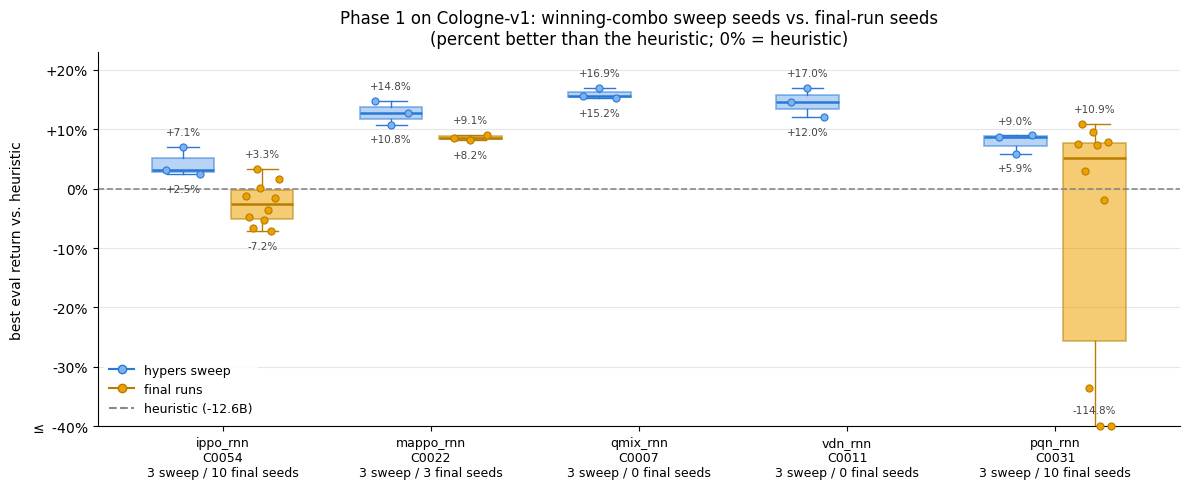

In [93]:
# Fixed group colors, never reassigned: the sweep reads as the light reference,
# the final runs as the foreground. Validated as a categorical pair
# (CVD ΔE 24.8, normal-vision ΔE 26.6). Both sit below 3:1 against white, which
# is why every value is also tabulated in the summary below.
GROUP_COLORS = {"sweep": "#7db2f0", "final": "#eda100"}
GROUP_EDGES = {"sweep": "#2a78d6", "final": "#b87c00"}
GROUP_LABELS = {"sweep": "hypers sweep", "final": "final runs"}
BASELINE_COLOR = "#888888"

billions_formatter = FuncFormatter(lambda v, _: f"{v / 1e9:,.1f}B")
millions_formatter = FuncFormatter(lambda v, _: f"{v / 1e6:,.0f}M")
def _percent_tick(value, _):
    if value == 0:
        return "0%"
    if value <= Y_FLOOR:
        return f"$\leq$ {Y_FLOOR:+,.0f}%"
    return f"{value:+,.0f}%"


percent_formatter = FuncFormatter(_percent_tick)


def relative_to_heuristic(values):
    """Returns as a percentage of the heuristic: 0 = heuristic, positive = better.

    Returns are negative costs, so a less negative return is an improvement and
    comes out positive here.
    """
    return (values - HEURISTIC_BASELINE) / abs(HEURISTIC_BASELINE) * 100

box_df = runs_df[runs_df["completed_frac"] >= MIN_COMPLETED_FRAC]
excluded = runs_df[runs_df["completed_frac"] < MIN_COMPLETED_FRAC]
if not excluded.empty:
    # Summarized per algorithm and group — mid-phase there can be a lot of these.
    detail = ", ".join(
        f"{alg}/{group} {len(group_runs)} run(s) at "
        f"{group_runs['completed_frac'].min():.0%}–{group_runs['completed_frac'].max():.0%}"
        for (alg, group), group_runs in excluded.groupby(["alg", "group"], observed=True)
    )
    print(
        f"Box plot excludes {len(excluded)} run(s) under {MIN_COMPLETED_FRAC:.0%} "
        f"of training: {detail}"
    )

# Two boxes per algorithm — sweep left, final right — for all five algorithms.
fig, ax = plt.subplots(figsize=(12.0, 5.0))

tick_labels = []
for index, alg in enumerate(ALG_ORDER):
    counts = {}
    for offset, group in [(-0.19, "sweep"), (0.19, "final")]:
        raw = box_df[(box_df["alg"] == alg) & (box_df["group"] == group)][
            "best"
        ].dropna()
        counts[group] = len(raw)
        if raw.empty:
            continue
        values = relative_to_heuristic(raw)

        box = ax.boxplot(
            [values.to_numpy()],
            positions=[index + offset],
            widths=0.3,
            patch_artist=True,
            medianprops={"color": GROUP_EDGES[group], "linewidth": 1.8},
            whiskerprops={"color": GROUP_EDGES[group], "linewidth": 1.0},
            capprops={"color": GROUP_EDGES[group], "linewidth": 1.0},
            showfliers=False,
        )
        for patch in box["boxes"]:
            patch.set(
                facecolor=GROUP_COLORS[group],
                edgecolor=GROUP_EDGES[group],
                linewidth=1.2,
                alpha=0.55,
            )

        # Every seed on top of its box, spread deterministically so points do
        # not overlap and the figure is reproducible run to run. Seeds below the
        # floor are drawn on it so a diverged run stays visible.
        spread = np.linspace(-0.08, 0.08, len(values)) if len(values) > 1 else [0.0]
        ax.scatter(
            index + offset + np.asarray(spread),
            np.clip(values.to_numpy(), Y_FLOOR, None),
            s=26,
            facecolor=GROUP_COLORS[group],
            edgecolors=GROUP_EDGES[group],
            linewidths=0.8,
            zorder=3,
            clip_on=False,
        )

        # Label the extremes of each box: best seed above, worst below. A worst
        # seed under the floor is labelled above the floor with its true value.
        for value, va, dy in [
            (values.max(), "bottom", 7),
            (values.min(), "top", -7),
        ]:
            if value < Y_FLOOR:
                va, dy = "bottom", 8
            ax.annotate(
                f"{value:+.1f}%",
                xy=(index + offset, max(value, Y_FLOOR)),
                xytext=(0, dy),
                textcoords="offset points",
                ha="center",
                va=va,
                fontsize=7.5,
                color="#444444",
            )

    combo = SWEEP_WINNERS[alg][1]
    tick_labels.append(
        f"{alg}\n{combo}\n{counts['sweep']} sweep / {counts['final']} final seeds"
    )

ax.axhline(0, color=BASELINE_COLOR, linestyle="--", linewidth=1.2)
ax.set_xticks(range(len(ALG_ORDER)))
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_xlim(-0.6, len(ALG_ORDER) - 0.4)
ax.yaxis.set_major_formatter(percent_formatter)
# The floor sits exactly on the bottom spine, so its tick reads as the limit.
visible = relative_to_heuristic(box_df["best"].dropna())
ax.set_ylim(Y_FLOOR, (visible.max() + 6) if len(visible) else 20)
ax.grid(axis="y", color="#e6e6e6", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

ax.set_ylabel("best eval return vs. heuristic")
handles = [
    Line2D(
        [], [], color=GROUP_EDGES[group], marker="o", linestyle="-",
        markerfacecolor=GROUP_COLORS[group], label=GROUP_LABELS[group],
    )
    for group in ["sweep", "final"]
] + [
    Line2D(
        [], [], color=BASELINE_COLOR, linestyle="--",
        label=f"heuristic ({HEURISTIC_BASELINE / 1e9:.1f}B)",
    )
]
ax.legend(
    handles=handles, fontsize=9, loc="lower left", frameon=True,
    framealpha=0.85, edgecolor="none",
)
ax.set_title(
    f"Phase 1 on {MAP_NAME}: winning-combo sweep seeds vs. final-run seeds\n"
    f"(percent better than the heuristic; 0% = heuristic)",
    fontsize=12,
)
fig.tight_layout()
plt.show()

## Learning curves

One panel per algorithm in a single row, one line per seed: sweep seeds light in
the background, final-run seeds in amber on top. Sweep and final seeds train for
the same number of steps with the same settings, so the curves are directly
comparable on `env_step`; a final-run curve that stops short is a seed still
training.

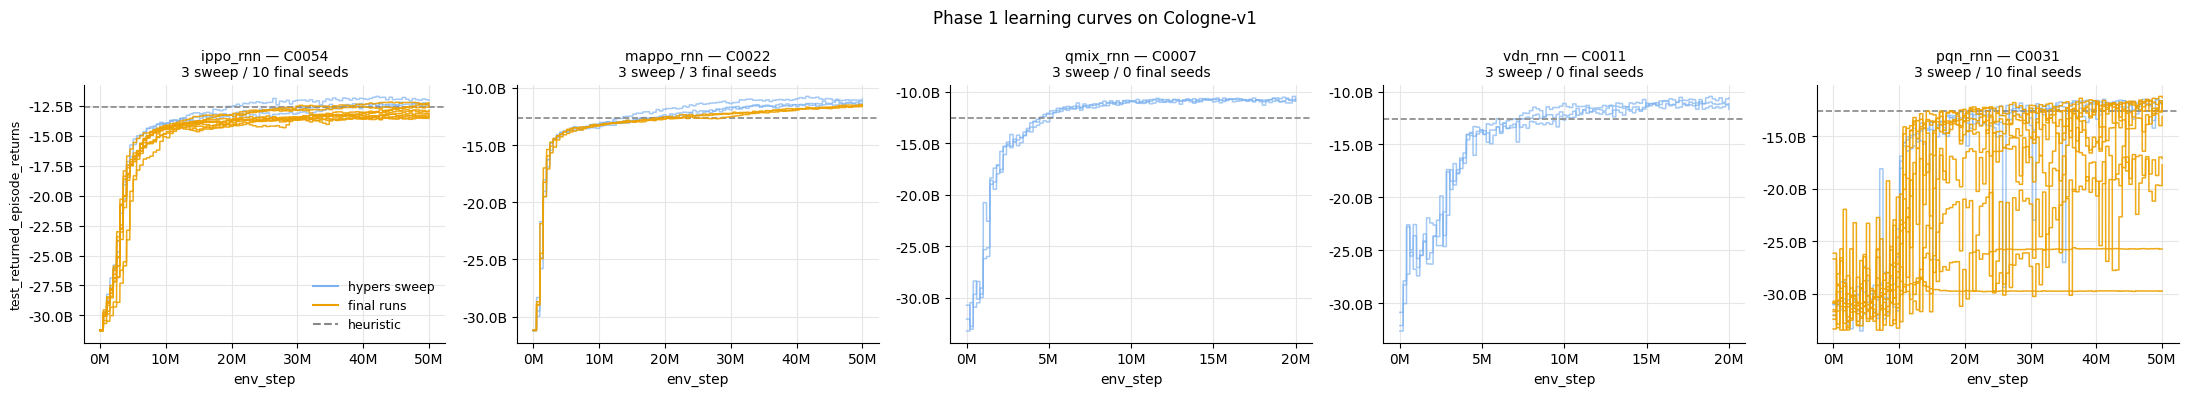

In [91]:
# Sweep curves are drawn lighter and underneath so the final runs read on top.
CURVE_STYLE = {
    "sweep": {"linewidth": 1.1, "alpha": 0.7, "zorder": 2},
    "final": {"linewidth": 1.1, "alpha": 0.9, "zorder": 3},
}

fig, axes = plt.subplots(
    1, len(ALG_ORDER), figsize=(4.4 * len(ALG_ORDER), 4.0), squeeze=False
)

for ax, alg in zip(axes[0], ALG_ORDER):
    counts = {}
    for group in ["sweep", "final"]:
        group_runs = runs_df[(runs_df["alg"] == alg) & (runs_df["group"] == group)]
        counts[group] = len(group_runs)
        for _, run_row in group_runs.iterrows():
            evals = eval_points(loaded_runs.get((run_row["project"], run_row["run_id"])))
            if evals.empty:
                continue
            ax.plot(
                evals["env_step"],
                evals[METRIC],
                color=GROUP_COLORS[group],
                **CURVE_STYLE[group],
            )

    ax.axhline(HEURISTIC_BASELINE, color=BASELINE_COLOR, linestyle="--", linewidth=1.2)
    ax.xaxis.set_major_formatter(millions_formatter)
    ax.yaxis.set_major_formatter(billions_formatter)
    ax.grid(color="#e6e6e6", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_title(
        f"{alg} — {SWEEP_WINNERS[alg][1]}\n"
        f"{counts['sweep']} sweep / {counts['final']} final seeds",
        fontsize=10,
    )
    ax.set_xlabel("env_step")

axes[0][0].set_ylabel(METRIC, fontsize=9)
handles = [
    Line2D([], [], color=GROUP_COLORS[group], label=GROUP_LABELS[group])
    for group in ["sweep", "final"]
] + [Line2D([], [], color=BASELINE_COLOR, linestyle="--", label="heuristic")]
axes[0][0].legend(handles=handles, fontsize=9, loc="lower right", frameon=False)

fig.suptitle(f"Phase 1 learning curves on {MAP_NAME}", fontsize=12)
fig.tight_layout()
plt.show()

## Summary

The best seed of each group and the difference between them, as a percentage of
the sweep's value (positive = the final runs came out ahead). `n` is how many
complete seeds each side rests on.

In [92]:
summary_rows = []
for alg in ALG_ORDER:
    entry = {"alg": alg}
    best = {}
    for group in ["sweep", "final"]:
        values = box_df[(box_df["alg"] == alg) & (box_df["group"] == group)][
            "best"
        ].dropna()
        best[group] = values.max()
        entry[f"{group}_n"] = len(values)
        entry[f"{group}_best"] = values.max()
    entry["diff_%"] = (best["final"] - best["sweep"]) / abs(best["sweep"]) * 100
    summary_rows.append(entry)

summary_df = pd.DataFrame(summary_rows).set_index("alg")
display(
    summary_df.style.format(
        {
            "sweep_best": lambda v: f"{v / 1e9:,.2f}B",
            "final_best": lambda v: f"{v / 1e9:,.2f}B",
            "diff_%": "{:+.2f}%",
        },
        na_rep="—",
    )
)

,sweep_n,sweep_best,final_n,final_best,diff_%
alg,,,,,
ippo_rnn,3,-11.71B,10,-12.18B,-4.00%
mappo_rnn,3,-10.74B,3,-11.46B,-6.69%
qmix_rnn,3,-10.47B,0,—,—
vdn_rnn,3,-10.46B,0,—,—
pqn_rnn,3,-11.47B,10,-11.23B,+2.10%
